In [1]:
#importing required python classes and packages
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from keras.utils.np_utils import to_categorical
import os
#loading resnet and attention model
from keras.applications.resnet50 import ResNet50, preprocess_input
from Attention import attention
from keras.preprocessing import image
from keras import layers, models, Input, Model
from keras.models import Sequential
from keras.layers import  MaxPooling2D, Conv2D, Flatten, Dense, Input, Concatenate, Dropout, RepeatVector
from sklearn.model_selection import train_test_split
from keras.callbacks import ModelCheckpoint
from keras.preprocessing.image import ImageDataGenerator
from keras.optimizers import Adam
import pickle
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

Using TensorFlow backend.
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:516: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint8 = np.dtype([("qint8", np.int8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:517: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_quint8 = np.dtype([("quint8", np.uint8, 1)])
c:\users\admin\appdata\local\programs\python\python37\lib\site-packages\tensorflow\python\framework\dtypes.py:518: FutureWarning: Passing (type, 1) or '1type' as a synonym of type is deprecated; in a future version of numpy, it will be understood as (type, (1,)) / '(1,)type'.
  _np_qint16 = np.dtype([("qint16", np.int16

In [16]:
#loading ISIC 2019 groundtruth dataset
isic_labels = ['MEL','NV','BCC','AK','BKL','DF','VASC','SCC']
groundtruth = pd.read_csv("Dataset/ISIC/ISIC_2019_Training_GroundTruth.csv")
groundtruth

,image,MEL,NV,BCC,AK,BKL,DF,VASC,SCC,UNK
0,ISIC_0000000,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,ISIC_0000001,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,ISIC_0000002,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,ISIC_0000003,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,ISIC_0000004,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...
25326,ISIC_0073247,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
25327,ISIC_0073248,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
25328,ISIC_0073249,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
25329,ISIC_0073251,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [17]:
#loaidng ISIC metadata features
metadata = pd.read_csv("Dataset/ISIC/ISIC_2019_Training_Metadata.csv", usecols=['image','age_approx','anatom_site_general','sex'])
groundtruth = groundtruth.values
metadata

,image,age_approx,anatom_site_general,sex
0,ISIC_0000000,55.0,anterior torso,female
1,ISIC_0000001,30.0,anterior torso,female
2,ISIC_0000002,60.0,upper extremity,female
3,ISIC_0000003,30.0,upper extremity,male
4,ISIC_0000004,80.0,posterior torso,male
...,...,...,...,...
25326,ISIC_0073247,85.0,head/neck,female
25327,ISIC_0073248,65.0,anterior torso,male
25328,ISIC_0073249,70.0,lower extremity,male
25329,ISIC_0073251,55.0,palms/soles,female


In [18]:
#applying onehot encoding on metadata features
le1 = LabelEncoder()
metadata['anatom_site_general'] = pd.Series(le1.fit_transform(metadata['anatom_site_general'].astype(str)))
le2 = LabelEncoder()
metadata['sex'] = pd.Series(le2.fit_transform(metadata['sex'].astype(str)))
metadata.fillna(metadata.mean(), inplace = True)
metadata

,image,age_approx,anatom_site_general,sex
0,ISIC_0000000,55.0,0,0
1,ISIC_0000001,30.0,0,0
2,ISIC_0000002,60.0,8,0
3,ISIC_0000003,30.0,8,1
4,ISIC_0000004,80.0,7,1
...,...,...,...,...
25326,ISIC_0073247,85.0,1,0
25327,ISIC_0073248,65.0,0,1
25328,ISIC_0073249,70.0,3,1
25329,ISIC_0073251,55.0,6,0


In [19]:
#loading resnet50 model for features extraction
resnet_model = ResNet50(weights='imagenet', include_top=False, pooling='avg')
print("Resnet50 model loaded")

Resnet50 model loaded


In [20]:
#read ISIC image and then apply Resnet to extract features
if os.path.exists("model/isic_img.npy"):
    img = np.load("model/isic_img.npy")
    X = np.load("model/isic_X.npy")
    Y = np.load("model/isic_Y.npy")
else:
    img = []
    X = []
    Y = []
    #loop all images
    for i in range(len(groundtruth)):
        img_name = groundtruth[i,0]#get image name
        arr = groundtruth[i,1:10]
        label_index = np.where(arr == 1)[0][0] #get label
        indices = metadata.loc[metadata['image'] == img_name].index[0]#get metadata index
        meta = metadata.iloc[indices].ravel()
        meta = meta[1:len(meta)].tolist()
        X.append(meta)
        #read and process image
        x = image.load_img("Dataset/ISIC/train-image/image/"+img_name+".jpg", target_size=(64, 64))
        x = image.img_to_array(x)
        x = np.expand_dims(x, axis=0) # Reshape to (1, 64, 64, 3)
        x = preprocess_input(x)
        img.append(x[0])
        Y.append(label_index)
    img = np.asarray(img)
    X = np.asarray(X)
    Y = np.asarray(Y)
    img = resnet_model.predict(img)#apply resnet to get features from processd images
    np.save("model/isic_img",img)
    np.save("model/isic_X",X)
    np.save("model/isic_Y",Y)
print("Total features extracted from each image by Resnet50 = "+str(img.shape[1]))
img = np.reshape(img, (img.shape[0], 64, 32, 1))   
print("Total ISIC images available in dataset = "+str(img.shape[0]))    

Total features extracted from each image by Resnet50 = 2048
Total ISIC images available in dataset = 25331


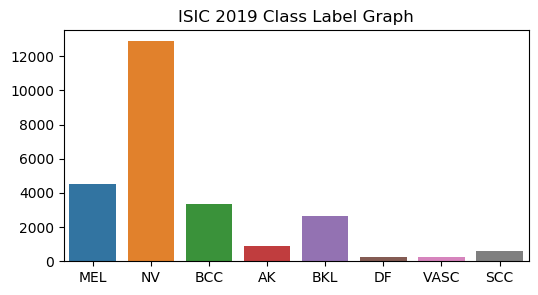

In [21]:
#graphs of different class labels available in dataset
unique, count = np.unique(Y,return_counts=True)
plt.figure(figsize=(6, 3))
sns.barplot(x=isic_labels,y=count)
plt.title("ISIC 2019 Class Label Graph")
plt.show() 

In [22]:
#shuffling images and metadata features
indices = np.arange(X.shape[0])
np.random.shuffle(indices)
X = X[indices] #X contains metadata
Y = Y[indices] #Y contains labels
img = img[indices] #img contains image features
Y = to_categorical(Y)
print("Features shuffling process completed")

Features shuffling process completed


In [23]:
#split dataset into train, test and validation for only images
X_train, X_test, y_train, y_test = train_test_split(img, Y, test_size=0.1, random_state=42, stratify=Y) 
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train) 

#split image and metadata features into train and test
X_img_train, X_img_test, X_meta_train, X_meta_test, y_trains, y_tests = train_test_split(img, X, Y, test_size=0.1, random_state=42, stratify=Y)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = train_test_split(X_img_train, X_meta_train, y_trains, test_size=0.2, random_state=42, stratify=y_trains)

print("Dataset Split Details")
print("70% dataset features used to train algorithms : "+str(X_train.shape[0]))
print("10% dataset features used to test algorithms : "+str(X_test.shape[0]))
print("20% dataset features used to validate algorithms : "+str(X_val.shape[0]))

Dataset Split Details
70% dataset features used to train algorithms : 18237
10% dataset features used to test algorithms : 2534
20% dataset features used to validate algorithms : 4560


In [24]:
#defining augmentation model
aug = ImageDataGenerator(rotation_range=20, width_shift_range=0.2, height_shift_range=0.2, shear_range=0.2, zoom_range=0.2,
                         horizontal_flip=True, fill_mode="nearest")

In [25]:
#function to evaluate model
def modelEvaluation(algorithm, testY, predict, prob):
    a = round(accuracy_score(testY,predict), 2)
    auc_value = roc_auc_score(testY,prob,multi_class='ovr')
    print(algorithm+" Accuracy  : "+str(a))
    print(algorithm+" AUC       : "+str(auc_value))
    print(classification_report(testY,predict, target_names=isic_labels))
    
    conf_matrix = confusion_matrix(testY, predict)
    fig, axs = plt.subplots(1,2,figsize=(10, 5))
    ax = sns.heatmap(conf_matrix, xticklabels = isic_labels, yticklabels = isic_labels, annot = True, cmap="viridis" ,fmt ="g", ax=axs[0]);
    ax.set_ylim([0,len(isic_labels)])
    axs[0].set_title(algorithm+" Confusion matrix") 
    color = ['red', 'green', 'blue', 'yellow', 'magenta', 'cyan', 'orange', 'black']
    for i in range(len(isic_labels)):   
        fpr, tpr, thresh = roc_curve(testY, prob[:,i], pos_label=i)
        axs[1].plot(fpr, tpr, linestyle='--',color=color[i], label=isic_labels[i])
    axs[1].set_title(algorithm+" ROC AUC Curve")
    axs[1].set_xlabel('False Positive Rate')
    axs[1].set_ylabel('True Positive rate')
    axs[1].legend()
    plt.show()

Image Only Model Accuracy  : 0.74
Image Only Model AUC       : 0.9455490147607444
              precision    recall  f1-score   support

         MEL       0.66      0.56      0.61       814
          NV       0.80      0.93      0.86      2318
         BCC       0.63      0.80      0.70       598
          AK       0.64      0.36      0.46       156
         BKL       0.63      0.42      0.50       472
          DF       1.00      0.12      0.21        43
        VASC       0.97      0.61      0.75        46
         SCC       1.00      0.03      0.05       113

    accuracy                           0.74      4560
   macro avg       0.79      0.48      0.52      4560
weighted avg       0.74      0.74      0.72      4560



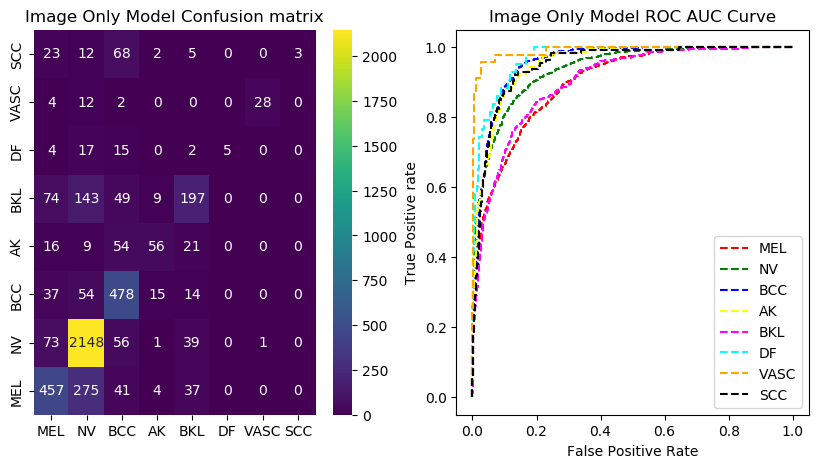

In [26]:
#training deep learning image only model
img_model = Sequential()
img_model.add(Conv2D(32, (3 , 3), input_shape = (X_train.shape[1], X_train.shape[2], X_train.shape[3]), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Conv2D(64, (3, 3), activation = 'relu'))
img_model.add(MaxPooling2D(pool_size = (2, 2)))
img_model.add(Flatten())
img_model.add(Dense(units = 128, activation = 'relu'))
img_model.add(Dropout(0.5))
img_model.add(Dense(units = y_train.shape[1], activation = 'softmax'))
#compiling, training and loading model
img_model.compile(optimizer = "adam", loss = 'categorical_crossentropy', metrics = ['accuracy'])
if os.path.exists("model/isic_img_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/isic_img_weights.hdf5', verbose = 1, save_best_only = True)
    hist = img_model.fit(X_train, y_train, batch_size = 32, epochs = 20, validation_data=(X_test, y_test), callbacks=[model_check_point], verbose=1)
    f = open('model/isic_img_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    img_model.load_weights("model/isic_img_weights.hdf5")
#perform prediction on test data    
prob = img_model.predict(X_val)
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_val, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image Only Model", y_test1, predict, prob)

Image + Metadata Accuracy  : 0.77
Image + Metadata AUC       : 0.9479518542591828
              precision    recall  f1-score   support

         MEL       0.72      0.63      0.67       814
          NV       0.86      0.90      0.88      2318
         BCC       0.69      0.77      0.73       598
          AK       0.53      0.51      0.52       156
         BKL       0.56      0.60      0.58       472
          DF       1.00      0.23      0.38        43
        VASC       0.83      0.74      0.78        46
         SCC       0.65      0.27      0.38       113

    accuracy                           0.77      4560
   macro avg       0.73      0.58      0.61      4560
weighted avg       0.77      0.77      0.76      4560



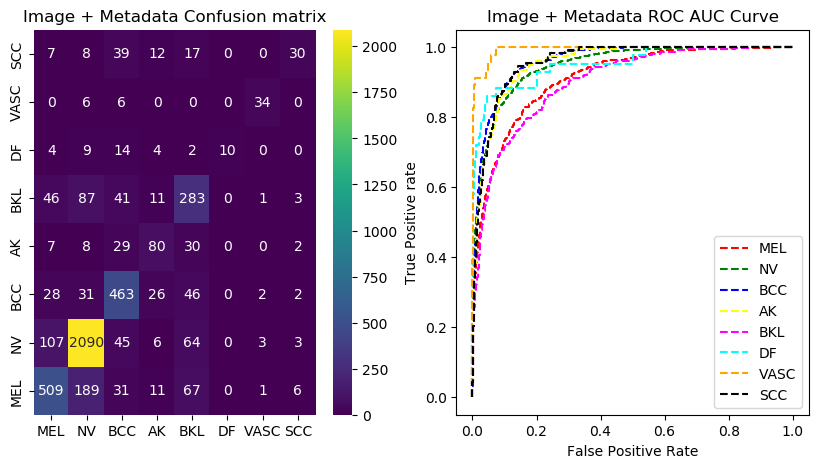

In [27]:
#training Image + Metadata (Concatenation) model
#split image and metadata features into train and test
data = np.load("model/isic_data.npy", allow_pickle=True)
X_img_train, X_img_val, X_meta_train, X_meta_val, y_trains, y_vals = data

#defining image model
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenating both models
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classification
meta_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
#compiling, training and loading model
meta_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
if os.path.exists("model/isic_meta_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/isic_meta_weights.hdf5', verbose = 1, save_best_only = True)
    hist = meta_model.fit([X_img_train, X_meta_train], y_trains,batch_size = 32, epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/isic_meta_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    meta_model.load_weights("model/isic_meta_weights.hdf5")
#perform prediction on test data
prob = meta_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Image + Metadata", y_test1, predict, prob)

Attention-Multimodal Fusion Accuracy  : 0.86
Attention-Multimodal Fusion AUC       : 0.9813570454467033
              precision    recall  f1-score   support

         MEL       0.79      0.79      0.79       814
          NV       0.91      0.95      0.93      2318
         BCC       0.79      0.90      0.84       598
          AK       0.86      0.69      0.77       156
         BKL       0.82      0.64      0.72       472
          DF       1.00      0.60      0.75        43
        VASC       0.87      0.89      0.88        46
         SCC       0.82      0.60      0.69       113

    accuracy                           0.86      4560
   macro avg       0.86      0.76      0.80      4560
weighted avg       0.86      0.86      0.86      4560



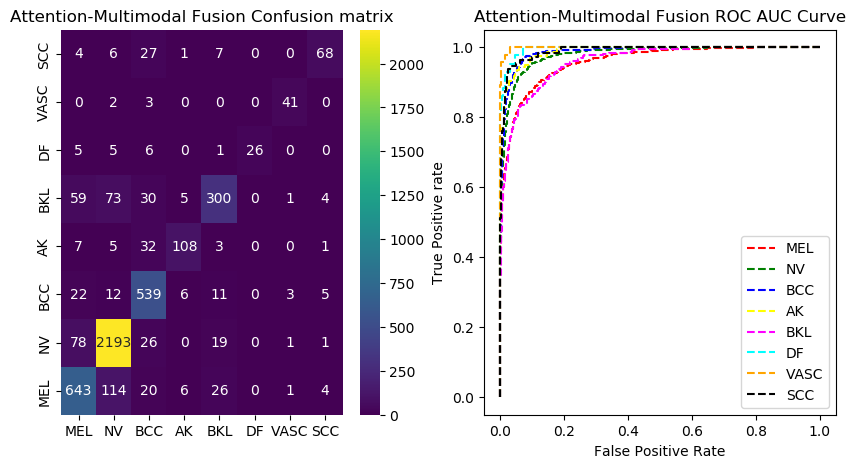

In [28]:
#Attention-based multimodal fusion
#defining image model with attention layer
image_branch = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(64, 32, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.25),
    Flatten(),
    RepeatVector(2),
    attention(return_sequences=True,name='imgattention'),
    Flatten(),
    Dense(64, activation='relu')
], name="Image_Branch")

#defining metadata model with attention layer
meta_branch = Sequential([
    Dense(32, activation='relu', input_shape=(X.shape[1],)),
    RepeatVector(2),
    attention(return_sequences=True,name='metaattention'),
    Flatten(),
    Dense(16, activation='relu')
], name="Metadata_Branch")

#concatenate image and metadata model with attention layer
combined_input = Concatenate()([image_branch.output, meta_branch.output])
# Final dense layers to process merged data
x = Dense(64, activation='relu')(combined_input)
output = Dense(Y.shape[1], activation='softmax')(x) # softmax activation for classifictaion
attention_model = Model(inputs=[image_branch.input, meta_branch.input], outputs=output)
attention_model.compile(optimizer="adam", loss='categorical_crossentropy', metrics=['accuracy'])
#compiling, training and loading model
if os.path.exists("model/isic_attention_weights.hdf5") == False:
    model_check_point = ModelCheckpoint(filepath='model/isic_attention_weights.hdf5', verbose = 1, save_best_only = True)
    hist = attention_model.fit([X_img_train, X_meta_train], y_trains,batch_size = 32, epochs = 20, validation_data=([X_img_test, X_meta_test], y_tests), callbacks=[model_check_point], verbose=1)
    f = open('model/isic_attention_history.pckl', 'wb')
    pickle.dump(hist.history, f)
    f.close()    
else:
    attention_model.load_weights("model/isic_attention_weights.hdf5")
#perform prediction on test data
prob = attention_model.predict([X_img_val, X_meta_val])
predict = np.argmax(prob, axis=1)
y_test1 = np.argmax(y_vals, axis=1)
#call this function to calculate accuracy and other metrics
modelEvaluation("Attention-Multimodal Fusion", y_test1, predict, prob)